In [3]:
import sys

assert sys.version_info >= (3, 7)

In [4]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the images/deep folder (if it doesn't already exist), and define the save_fig() function which is used through this notebook to save the figures in high-res for the book:

In [6]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "deep"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Vanishing/Exploding Gradients Problem

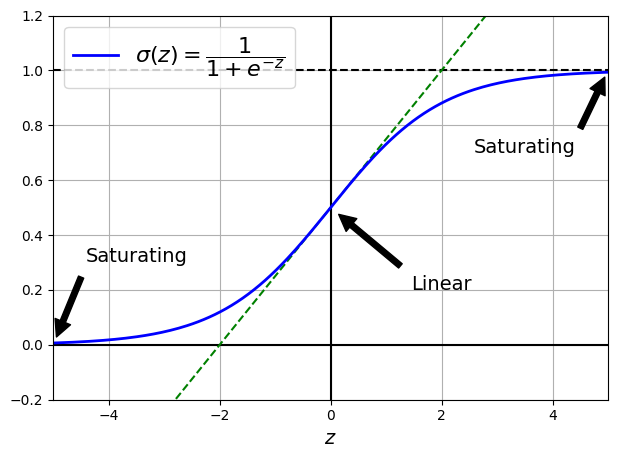

In [7]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

save_fig("sigmoid_saturation_plot")
plt.show()

# Xavier and He Initialization

In [8]:
dense = tf.keras.layers.Dense(50, activation="relu",
                              kernel_initializer="he_normal")

In [9]:
he_avg_init = tf.keras.initializers.VarianceScaling(scale=2., mode="fan_avg",
                                                    distribution="uniform")
dense = tf.keras.layers.Dense(50, activation="sigmoid",
                              kernel_initializer=he_avg_init)

# Nonsaturating Activation Functions
## Leaky ReLU

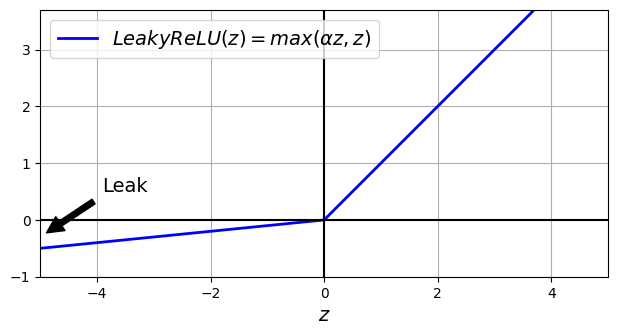

In [10]:
def leaky_relu(z, alpha):
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

save_fig("leaky_relu_plot")
plt.show()

In [11]:
leaky_relu = tf.keras.layers.LeakyReLU(alpha=0.2)  # defaults to alpha=0.3
dense = tf.keras.layers.Dense(50, activation=leaky_relu,
                              kernel_initializer="he_normal")

In [12]:
model = tf.keras.models.Sequential([
    # [...]  # more layers
    tf.keras.layers.Dense(50, kernel_initializer="he_normal"),  # no activation
    tf.keras.layers.LeakyReLU(alpha=0.2),  # activation as a separate layer
    # [...]  # more layers
])

# ELU
Implementing ELU in TensorFlow is trivial, just specify the activation function when building each layer, and use He initialization:

In [13]:
dense = tf.keras.layers.Dense(50, activation="elu",
                              kernel_initializer="he_normal")

# SELU
By default, the SELU hyperparameters (scale and alpha) are tuned in such a way that the mean output of each neuron remains close to 0, and the standard deviation remains close to 1 (assuming the inputs are standardized with mean 0 and standard deviation 1 too, and other constraints are respected, as explained in the book). Using this activation function, even a 1,000 layer deep neural network preserves roughly mean 0 and standard deviation 1 across all layers, avoiding the exploding/vanishing gradients problem:

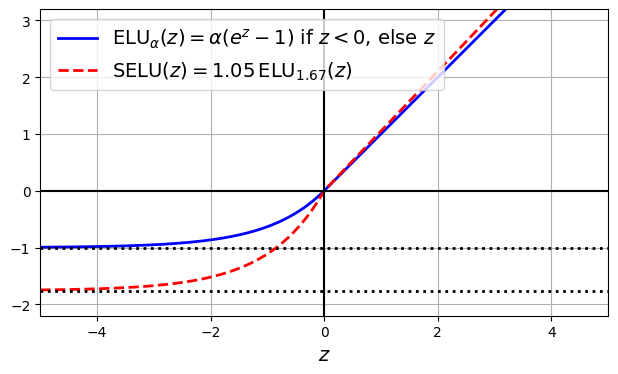

In [14]:
from scipy.special import erfc

# alpha and scale to self normalize with mean 0 and standard deviation 1
# (see equation 14 in the paper):
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ if $z < 0$, else $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

save_fig("elu_selu_plot")
plt.show()

Using SELU is straightforward:

In [15]:
dense = tf.keras.layers.Dense(50, activation="selu",
                              kernel_initializer="lecun_normal")

Let's create a neural net for Fashion MNIST with 100 hidden layers, using the SELU activation function:

In [17]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="selu",
                                    kernel_initializer="lecun_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [18]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

Now let's train it. Do not forget to scale the inputs to mean 0 and standard deviation 1:

In [20]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

In [21]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [22]:
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [23]:
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5


1719/1719 [==============================] - 31s 13ms/step - loss: 1.6342 - accuracy: 0.3608 - val_loss: 1.6092 - val_accuracy: 0.4252
Epoch 2/5
1719/1719 [==============================] - 22s 13ms/step - loss: 0.9767 - accuracy: 0.6325 - val_loss: 0.8185 - val_accuracy: 0.7278
Epoch 3/5
1719/1719 [==============================] - 22s 13ms/step - loss: 0.7564 - accuracy: 0.7312 - val_loss: 0.6924 - val_accuracy: 0.7604
Epoch 4/5
1719/1719 [==============================] - 21s 12ms/step - loss: 0.6748 - accuracy: 0.7617 - val_loss: 0.6326 - val_accuracy: 0.7870
Epoch 5/5
1719/1719 [==============================] - 21s 12ms/step - loss: 0.6215 - accuracy: 0.7812 - val_loss: 0.6553 - val_accuracy: 0.7790


In [24]:
tf.random.set_seed(42)

In [25]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="relu",
                                    kernel_initializer="he_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [26]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_107 (Dense)           (None, 100)               78500     
                                                                 
 dense_108 (Dense)           (None, 100)               10100     
                                                                 
 dense_109 (Dense)           (None, 100)               10100     
                                                                 
 dense_110 (Dense)           (None, 100)               10100     
                                                                 
 dense_111 (Dense)           (None, 100)               10100     
                                                                 
 dense_112 (Dense)           (None, 100)              

In [27]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

In [28]:
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 [==============================] - 26s 12ms/step - loss: 2.0990 - accuracy: 0.1652 - val_loss: 1.4941 - val_accuracy: 0.3616
Epoch 2/5
1719/1719 [==============================] - 19s 11ms/step - loss: 1.3135 - accuracy: 0.4304 - val_loss: 1.6687 - val_accuracy: 0.2976
Epoch 3/5
1719/1719 [==============================] - 19s 11ms/step - loss: 1.0339 - accuracy: 0.5540 - val_loss: 0.9004 - val_accuracy: 0.6328
Epoch 4/5
1719/1719 [==============================] - 19s 11ms/step - loss: 0.9141 - accuracy: 0.6365 - val_loss: 0.8270 - val_accuracy: 0.6866
Epoch 5/5
1719/1719 [==============================] - 19s 11ms/step - loss: 0.8010 - accuracy: 0.6936 - val_loss: 0.8548 - val_accuracy: 0.6610


Not great at all, we suffered from the vanishing/exploding gradients problem.

# GELU, Swish and Mish

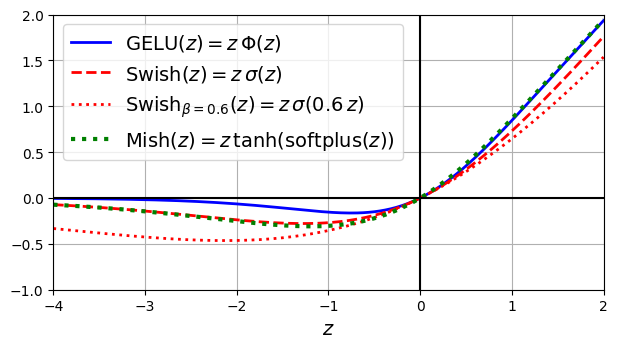

In [29]:
def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta=1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

z = np.linspace(-4, 2, 200)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "g:", linewidth=3,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

save_fig("gelu_swish_mish_plot")
plt.show()

# Batch Normalization

In [30]:
# extra code - clear the name counters and set the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(300, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [32]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 batch_normalization (Batch  (None, 784)               3136      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 batch_normalization_1 (Bat  (None, 300)               1200      
 chNormalization)                                                
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 batch_normalization_2 (Bat  (None, 100)               4

In [33]:
[(var.name, var.trainable) for var in model.layers[1].variables]

[('batch_normalization/gamma:0', True),
 ('batch_normalization/beta:0', True),
 ('batch_normalization/moving_mean:0', False),
 ('batch_normalization/moving_variance:0', False)]

In [34]:
# extra code – just show that the model works! 😊
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))


Epoch 1/2
1719/1719 [==============================] - 8s 4ms/step - loss: 0.5563 - accuracy: 0.8062 - val_loss: 0.4017 - val_accuracy: 0.8502
Epoch 2/2
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4018 - accuracy: 0.8561 - val_loss: 0.3594 - val_accuracy: 0.8660


Sometimes applying BN before the activation function works better (there's a debate on this topic). Moreover, the layer before a BatchNormalization layer does not need to have bias terms, since the BatchNormalization layer some as well, it would be a waste of parameters, so you can set use_bias=False when creating those layers:

In [36]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [37]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [38]:
# extra code – just show that the model works! 😊
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 [==============================] - 7s 3ms/step - loss: 0.6001 - accuracy: 0.7997 - val_loss: 0.4268 - val_accuracy: 0.8482
Epoch 2/2
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4247 - accuracy: 0.8520 - val_loss: 0.3751 - val_accuracy: 0.8674


# Gradient Clipping

All tf.keras.optimizers accept clipnorm or clipvalue arguments:

In [40]:
optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

In [41]:
optimizer = tf.keras.optimizers.SGD(clipnorm=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

# Reusing Pretrained Layers
## Reusing a Keras model
Let's split the fashion MNIST training set in two:

X_train_A: all images of all items except for T-shirts/tops and pullovers (classes 0 and 2).
X_train_B: a much smaller training set of just the first 200 images of T-shirts/tops and pullovers.
The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (trousers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots) are somewhat similar to classes in set B (T-shirts/tops and pullovers). However, since we are using Dense layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image, as we will see in the chapter 14).

In [44]:
# extra code – split Fashion MNIST into tasks A and B, then train and save
#              model A to "my_model_A".

pos_class_id = class_names.index("Pullover")
neg_class_id = class_names.index("T-shirt/top")

def split_dataset(X, y):
    y_for_B = (y == pos_class_id) | (y == neg_class_id)
    y_A = y[~y_for_B]
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32)
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id]))
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # reorder class ids for A
    return ((X[~y_for_B], y_A), (X[y_for_B], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

tf.random.set_seed(42)

model_A = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(8, activation="softmax")
])

model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A))
model_A.save("my_model_A.keras")

Epoch 1/20
1376/1376 [==============================] - 8s 5ms/step - loss: 1.2307 - accuracy: 0.6196 - val_loss: 0.7162 - val_accuracy: 0.7746
Epoch 2/20
1376/1376 [==============================] - 6s 4ms/step - loss: 0.6121 - accuracy: 0.7991 - val_loss: 0.5219 - val_accuracy: 0.8308
Epoch 3/20
1376/1376 [==============================] - 6s 4ms/step - loss: 0.4882 - accuracy: 0.8422 - val_loss: 0.4450 - val_accuracy: 0.8526
Epoch 4/20
1376/1376 [==============================] - 6s 4ms/step - loss: 0.4262 - accuracy: 0.8610 - val_loss: 0.4005 - val_accuracy: 0.8634
Epoch 5/20
1376/1376 [==============================] - 6s 4ms/step - loss: 0.3887 - accuracy: 0.8721 - val_loss: 0.3737 - val_accuracy: 0.8704
Epoch 6/20
1376/1376 [==============================] - 6s 4ms/step - loss: 0.3631 - accuracy: 0.8787 - val_loss: 0.3543 - val_accuracy: 0.8732
Epoch 7/20
1376/1376 [==============================] - 6s 4ms/step - loss: 0.3454 - accuracy: 0.8824 - val_loss: 0.3407 - val_accuracy:

In [45]:
tf.random.set_seed(42)
model_B = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_B.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_B.fit(X_train_B, y_train_B, epochs=20,
                      validation_data=(X_valid_B, y_valid_B))
model_B.evaluate(X_test_B, y_test_B)

Epoch 1/20
7/7 [==============================] - 2s 96ms/step - loss: 0.8875 - accuracy: 0.5550 - val_loss: 0.8410 - val_accuracy: 0.5153
Epoch 2/20
7/7 [==============================] - 0s 30ms/step - loss: 0.7594 - accuracy: 0.5550 - val_loss: 0.7524 - val_accuracy: 0.5163
Epoch 3/20
7/7 [==============================] - 0s 30ms/step - loss: 0.6898 - accuracy: 0.5500 - val_loss: 0.6993 - val_accuracy: 0.5193
Epoch 4/20
7/7 [==============================] - 0s 27ms/step - loss: 0.6438 - accuracy: 0.5700 - val_loss: 0.6564 - val_accuracy: 0.5470
Epoch 5/20
7/7 [==============================] - 0s 27ms/step - loss: 0.6073 - accuracy: 0.6150 - val_loss: 0.6195 - val_accuracy: 0.6380
Epoch 6/20
7/7 [==============================] - 0s 27ms/step - loss: 0.5750 - accuracy: 0.7200 - val_loss: 0.5884 - val_accuracy: 0.7319
Epoch 7/20
7/7 [==============================] - 0s 32ms/step - loss: 0.5461 - accuracy: 0.7850 - val_loss: 0.5610 - val_accuracy: 0.7972
Epoch 8/20
7/7 [===========

[0.3798096477985382, 0.9175000190734863]

Model B reaches 91.85% accuracy on the test set. Now let's try reusing the pretrained model A.

In [47]:
model_A = tf.keras.models.load_model("my_model_A.keras")
model_B_on_A = tf.keras.Sequential(model_A.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

Note that model_B_on_A and model_A actually share layers now, so when we train one, it will update both models. If we want to avoid that, we need to build model_B_on_A on top of a clone of model_A:

In [49]:
tf.random.set_seed(42)  # extra code – ensure reproducibility

In [50]:
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

In [51]:
# extra code – creating model_B_on_A just like in the previous cell
model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [52]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])

In [53]:
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))

Epoch 1/4
7/7 [==============================] - 1s 86ms/step - loss: 1.1062 - accuracy: 0.4500 - val_loss: 0.7256 - val_accuracy: 0.5114
Epoch 2/4
7/7 [==============================] - 0s 27ms/step - loss: 0.6854 - accuracy: 0.5350 - val_loss: 0.5964 - val_accuracy: 0.6301
Epoch 3/4
7/7 [==============================] - 0s 28ms/step - loss: 0.5963 - accuracy: 0.6800 - val_loss: 0.5827 - val_accuracy: 0.7507
Epoch 4/4
7/7 [==============================] - 0s 26ms/step - loss: 0.5752 - accuracy: 0.7800 - val_loss: 0.5740 - val_accuracy: 0.7616
Epoch 1/16
7/7 [==============================] - 6s 83ms/step - loss: 0.5421 - accuracy: 0.8150 - val_loss: 0.4948 - val_accuracy: 0.8516
Epoch 2/16
7/7 [==============================] - 0s 29ms/step - loss: 0.4744 - accuracy: 0.8850 - val_loss: 0.4385 - val_accuracy: 0.8912
Epoch 3/16
7/7 [==============================] - 0s 29ms/step - loss: 0.4193 - accuracy: 0.9150 - val_loss: 0.4084 - val_accuracy: 0.8892
Epoch 4/16
7/7 [===============

In [54]:
model_B_on_A.evaluate(X_test_B, y_test_B)

63/63 [==============================] - 0s 3ms/step - loss: 0.2443 - accuracy: 0.9330


[0.24430760741233826, 0.9330000281333923]

Great! We got a bit of transfer: the model's accuracy went up 2 percentage points, from 91.85% to 93.85%. This means the error rate dropped by almost 25%

In [56]:
1 - (100 - 93.85) / (100 - 91.85)

0.24539877300613477

# Faster Optimizers

In [58]:
def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[28, 28]),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

def build_and_train_model(optimizer):
    model = build_model()
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

In [59]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

In [60]:
history_sgd = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 5s 2ms/step - loss: 1.3539 - accuracy: 0.5691 - val_loss: 0.8582 - val_accuracy: 0.7140
Epoch 2/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.7672 - accuracy: 0.7372 - val_loss: 0.6735 - val_accuracy: 0.7648
Epoch 3/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.6481 - accuracy: 0.7747 - val_loss: 0.5955 - val_accuracy: 0.7886
Epoch 4/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5890 - accuracy: 0.7970 - val_loss: 0.5557 - val_accuracy: 0.8072
Epoch 5/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5526 - accuracy: 0.8085 - val_loss: 0.5305 - val_accuracy: 0.8186
Epoch 6/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5270 - accuracy: 0.8172 - val_loss: 0.5143 - val_accuracy: 0.8194
Epoch 7/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5081 - accuracy: 0.8236 - val_loss: 0.4936 - val_accuracy:

# Momentum optimization

In [62]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

In [63]:
history_momentum = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 5s 2ms/step - loss: 0.7173 - accuracy: 0.7555 - val_loss: 0.5303 - val_accuracy: 0.8080
Epoch 2/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4718 - accuracy: 0.8353 - val_loss: 0.4494 - val_accuracy: 0.8344
Epoch 3/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4260 - accuracy: 0.8498 - val_loss: 0.4183 - val_accuracy: 0.8538
Epoch 4/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3972 - accuracy: 0.8601 - val_loss: 0.3832 - val_accuracy: 0.8628
Epoch 5/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3744 - accuracy: 0.8676 - val_loss: 0.3657 - val_accuracy: 0.8668
Epoch 6/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3605 - accuracy: 0.8711 - val_loss: 0.3664 - val_accuracy: 0.8684
Epoch 7/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3436 - accuracy: 0.8774 - val_loss: 0.3643 - val_accuracy:

# Nesterov Accelerated Gradient

In [65]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9,
                                    nesterov=True)

In [66]:
history_nesterov = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 5s 2ms/step - loss: 0.6975 - accuracy: 0.7642 - val_loss: 0.4914 - val_accuracy: 0.8258
Epoch 2/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4627 - accuracy: 0.8378 - val_loss: 0.4293 - val_accuracy: 0.8460
Epoch 3/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4200 - accuracy: 0.8524 - val_loss: 0.4065 - val_accuracy: 0.8562
Epoch 4/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3940 - accuracy: 0.8631 - val_loss: 0.3814 - val_accuracy: 0.8650
Epoch 5/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3723 - accuracy: 0.8684 - val_loss: 0.3740 - val_accuracy: 0.8650
Epoch 6/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3577 - accuracy: 0.8728 - val_loss: 0.3750 - val_accuracy: 0.8696
Epoch 7/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3427 - accuracy: 0.8769 - val_loss: 0.3777 - val_accuracy:

# AdaGrad

In [68]:
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)

In [69]:
history_adagrad = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 5s 3ms/step - loss: 1.0017 - accuracy: 0.6741 - val_loss: 0.6841 - val_accuracy: 0.7672
Epoch 2/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.6402 - accuracy: 0.7861 - val_loss: 0.5817 - val_accuracy: 0.8014
Epoch 3/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5710 - accuracy: 0.8088 - val_loss: 0.5380 - val_accuracy: 0.8176
Epoch 4/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5354 - accuracy: 0.8199 - val_loss: 0.5141 - val_accuracy: 0.8262
Epoch 5/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5118 - accuracy: 0.8281 - val_loss: 0.4959 - val_accuracy: 0.8326
Epoch 6/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4950 - accuracy: 0.8320 - val_loss: 0.4839 - val_accuracy: 0.8348
Epoch 7/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4822 - accuracy: 0.8352 - val_loss: 0.4713 - val_accuracy:

# RMSProp

In [71]:
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

In [72]:
history_rmsprop = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 5s 2ms/step - loss: 0.5137 - accuracy: 0.8131 - val_loss: 0.4199 - val_accuracy: 0.8412
Epoch 2/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3929 - accuracy: 0.8575 - val_loss: 0.4333 - val_accuracy: 0.8412
Epoch 3/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3664 - accuracy: 0.8691 - val_loss: 0.4059 - val_accuracy: 0.8604
Epoch 4/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3585 - accuracy: 0.8750 - val_loss: 0.3931 - val_accuracy: 0.8648
Epoch 5/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3536 - accuracy: 0.8757 - val_loss: 0.3788 - val_accuracy: 0.8684
Epoch 6/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3517 - accuracy: 0.8785 - val_loss: 0.4313 - val_accuracy: 0.8646
Epoch 7/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3553 - accuracy: 0.8769 - val_loss: 0.4093 - val_accuracy:

# Adam Optimization

In [74]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9,
                                     beta_2=0.999)

In [75]:
history_adam = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.5012 - accuracy: 0.8217 - val_loss: 0.4243 - val_accuracy: 0.8390
Epoch 2/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3739 - accuracy: 0.8632 - val_loss: 0.3896 - val_accuracy: 0.8512
Epoch 3/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3379 - accuracy: 0.8759 - val_loss: 0.3531 - val_accuracy: 0.8738
Epoch 4/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3140 - accuracy: 0.8847 - val_loss: 0.3351 - val_accuracy: 0.8800
Epoch 5/10
1719/1719 [==============================] - 4s 3ms/step - loss: 0.2966 - accuracy: 0.8898 - val_loss: 0.3112 - val_accuracy: 0.8816
Epoch 6/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2806 - accuracy: 0.8949 - val_loss: 0.3380 - val_accuracy: 0.8802
Epoch 7/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2696 - accuracy: 0.8988 - val_loss: 0.3310 - val_accuracy:

## Adamax Optimization

In [76]:
optimizer = tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9,
                                       beta_2=0.999)

In [77]:
history_adamax = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.5443 - accuracy: 0.8110 - val_loss: 0.4577 - val_accuracy: 0.8308
Epoch 2/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3966 - accuracy: 0.8582 - val_loss: 0.4000 - val_accuracy: 0.8472
Epoch 3/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3595 - accuracy: 0.8704 - val_loss: 0.3676 - val_accuracy: 0.8656
Epoch 4/10
1719/1719 [==============================] - 4s 3ms/step - loss: 0.3354 - accuracy: 0.8791 - val_loss: 0.3489 - val_accuracy: 0.8720
Epoch 5/10
1719/1719 [==============================] - 4s 3ms/step - loss: 0.3150 - accuracy: 0.8849 - val_loss: 0.3343 - val_accuracy: 0.8746
Epoch 6/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2999 - accuracy: 0.8906 - val_loss: 0.3385 - val_accuracy: 0.8770
Epoch 7/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2866 - accuracy: 0.8935 - val_loss: 0.3300 - val_accuracy:

## Nadam Optimization

In [78]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9,
                                      beta_2=0.999)

In [79]:
history_nadam = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 7s 3ms/step - loss: 0.4797 - accuracy: 0.8294 - val_loss: 0.3967 - val_accuracy: 0.8488
Epoch 2/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3649 - accuracy: 0.8665 - val_loss: 0.3764 - val_accuracy: 0.8578
Epoch 3/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3338 - accuracy: 0.8773 - val_loss: 0.3536 - val_accuracy: 0.8730
Epoch 4/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3135 - accuracy: 0.8846 - val_loss: 0.3324 - val_accuracy: 0.8796
Epoch 5/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2937 - accuracy: 0.8897 - val_loss: 0.3286 - val_accuracy: 0.8788
Epoch 6/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2800 - accuracy: 0.8952 - val_loss: 0.3646 - val_accuracy: 0.8716
Epoch 7/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2686 - accuracy: 0.8987 - val_loss: 0.3478 - val_accuracy:

## AdamW Optimization

In [80]:
optimizer = tf.keras.optimizers.AdamW(weight_decay=1e-5, learning_rate=0.001,
                                      beta_1=0.9, beta_2=0.999)

In [81]:
history_adamw = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4923 - accuracy: 0.8224 - val_loss: 0.4283 - val_accuracy: 0.8304
Epoch 2/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3729 - accuracy: 0.8630 - val_loss: 0.3882 - val_accuracy: 0.8480
Epoch 3/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3401 - accuracy: 0.8741 - val_loss: 0.3489 - val_accuracy: 0.8744
Epoch 4/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3164 - accuracy: 0.8826 - val_loss: 0.3362 - val_accuracy: 0.8756
Epoch 5/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2984 - accuracy: 0.8897 - val_loss: 0.3284 - val_accuracy: 0.8778
Epoch 6/10
1719/1719 [==============================] - 4s 3ms/step - loss: 0.2830 - accuracy: 0.8942 - val_loss: 0.3493 - val_accuracy: 0.8808
Epoch 7/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2747 - accuracy: 0.8983 - val_loss: 0.3620 - val_accuracy:

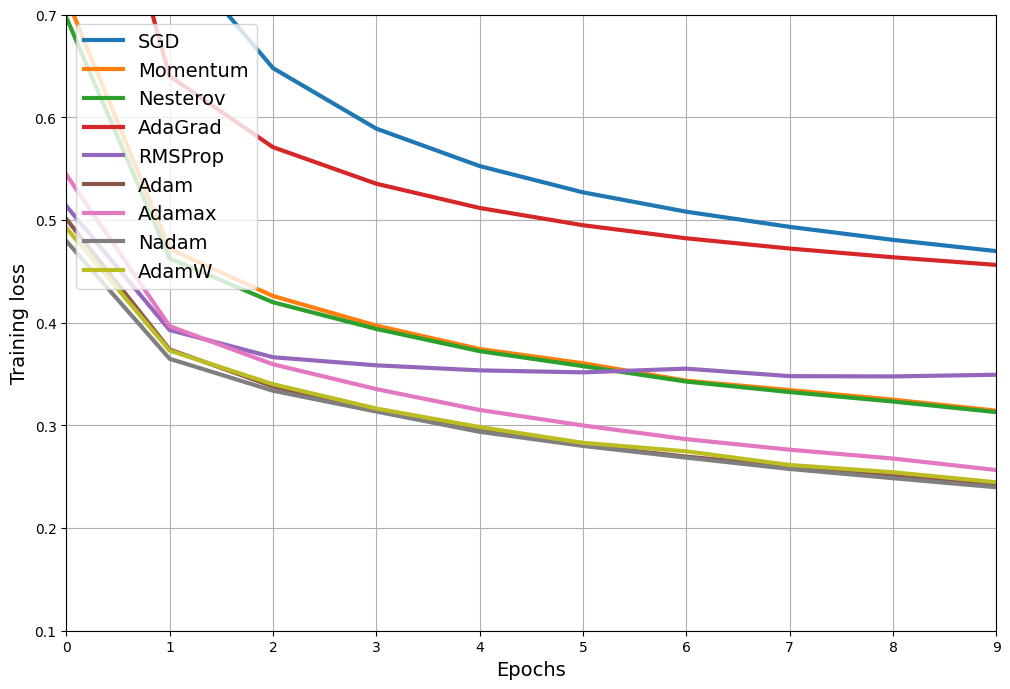

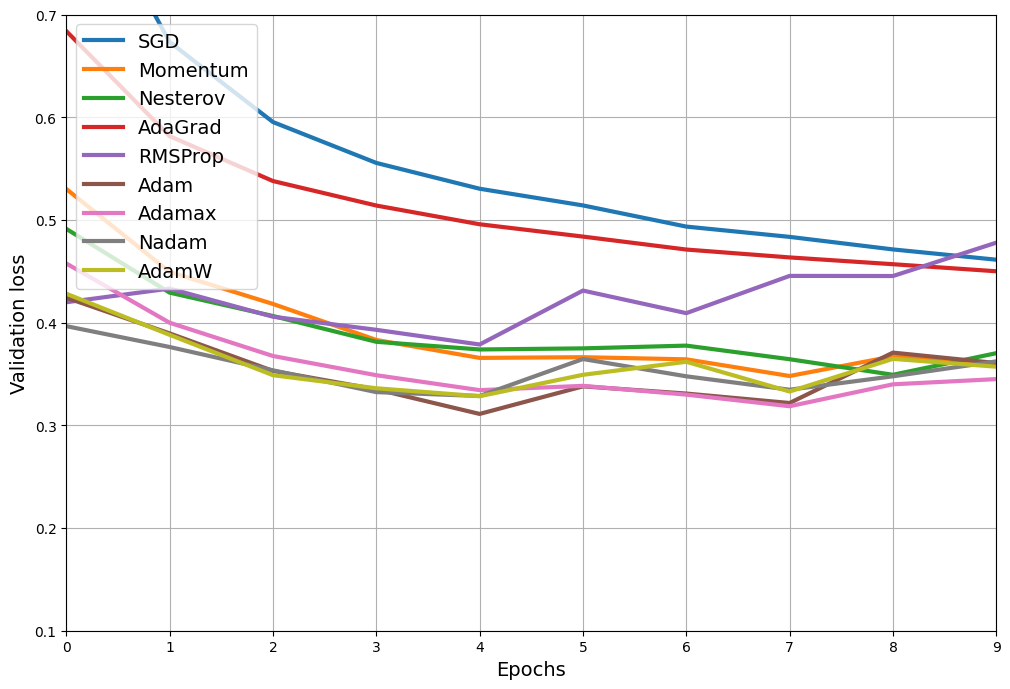

In [82]:
# extra code – visualize the learning curves of all the optimizers

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip((history_sgd, history_momentum, history_nesterov,
                                  history_adagrad, history_rmsprop, history_adam,
                                  history_adamax, history_nadam, history_adamw),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0.1, 0.7])
    plt.show()

# Learning Rate Scheduling
## Power Scheduling

learning_rate = initial_learning_rate / (1 + step / decay_steps)**power
Keras uses power = 1.

Note: Optimizers used to have a decay argument for this, but it was deprecated. You must use the schedulers in tf.keras.optimizers.schedules instead.

In [85]:
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=10_000,
    decay_rate=1.0,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

The InverseTimeDecay scheduler uses learning_rate = initial_learning_rate / (1 + decay_rate * step / decay_steps). If you set staircase=True, then it replaces step / decay_step with floor(step / decay_step).

In [87]:
history_power_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.6925 - accuracy: 0.7609 - val_loss: 0.4950 - val_accuracy: 0.8256
Epoch 2/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4772 - accuracy: 0.8328 - val_loss: 0.4524 - val_accuracy: 0.8384
Epoch 3/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4303 - accuracy: 0.8486 - val_loss: 0.4263 - val_accuracy: 0.8526
Epoch 4/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4068 - accuracy: 0.8572 - val_loss: 0.3960 - val_accuracy: 0.8604
Epoch 5/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3878 - accuracy: 0.8645 - val_loss: 0.3828 - val_accuracy: 0.8600
Epoch 6/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.3733 - accuracy: 0.8685 - val_loss: 0.3896 - val_accuracy: 0.8602
Epoch 7/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3630 - accuracy: 0.8715 - val_loss: 0.3758 - val_accuracy:

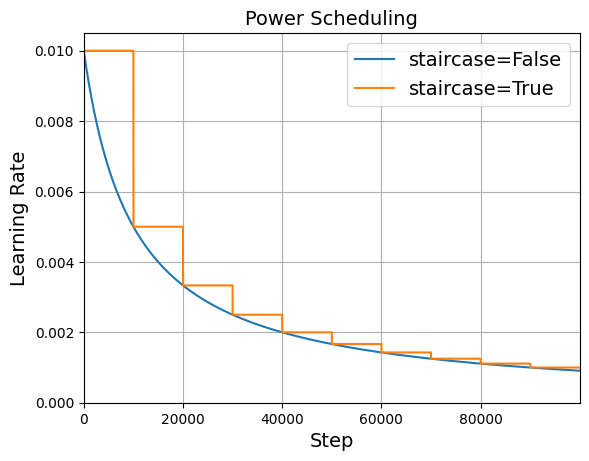

In [88]:
# extra code – this cell plots power scheduling with staircase=True or False

initial_learning_rate = 0.01
decay_rate = 1.0
decay_steps = 10_000

steps = np.arange(100_000)
lrs = initial_learning_rate / (1 + decay_rate * steps / decay_steps)
lrs2 = initial_learning_rate / (1 + decay_rate * np.floor(steps / decay_steps))

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Power Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Exponential Scheduling
learning_rate = initial_learning_rate * decay_rate ** (step / decay_steps)

In [90]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=20_000,
    decay_rate=0.1,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

In [91]:
history_exponential_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.6850 - accuracy: 0.7675 - val_loss: 0.4965 - val_accuracy: 0.8218
Epoch 2/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4703 - accuracy: 0.8347 - val_loss: 0.4507 - val_accuracy: 0.8360
Epoch 3/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4250 - accuracy: 0.8497 - val_loss: 0.4175 - val_accuracy: 0.8524
Epoch 4/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4031 - accuracy: 0.8576 - val_loss: 0.3901 - val_accuracy: 0.8606
Epoch 5/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3861 - accuracy: 0.8638 - val_loss: 0.3830 - val_accuracy: 0.8616
Epoch 6/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3742 - accuracy: 0.8673 - val_loss: 0.3865 - val_accuracy: 0.8636
Epoch 7/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3658 - accuracy: 0.8702 - val_loss: 0.3730 - val_accuracy:

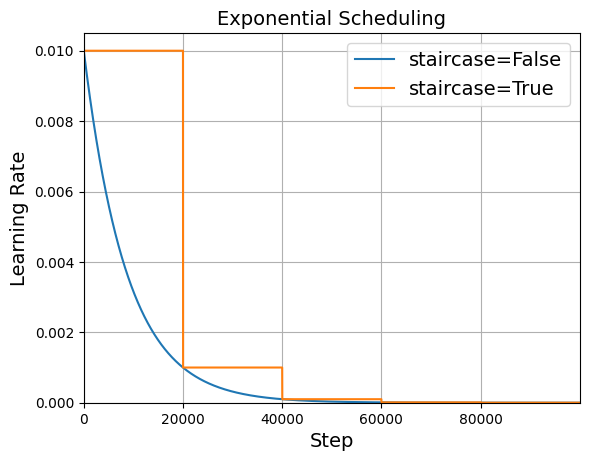

In [92]:
# extra code – this cell plots exponential scheduling

initial_learning_rate = 0.01
decay_rate = 0.1
decay_steps = 20_000

steps = np.arange(100_000)
lrs = initial_learning_rate * decay_rate ** (steps / decay_steps)
lrs2 = initial_learning_rate * decay_rate ** np.floor(steps / decay_steps)

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Exponential Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

Keras also provides a LearningRateScheduler callback class that lets you define your own scheduling function. Let's see how you could use it to implement exponential decay. Note that in this case the learning rate only changes at each epoch, not at each step:

In [93]:
def exponential_decay_fn(epoch):
    return 0.01 * 0.1 ** (epoch / 20)

In [94]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.01, s=20)

In [95]:
# extra code – build and compile a model for Fashion MNIST

tf.random.set_seed(42)
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [96]:
n_epochs = 20

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/20
1719/1719 [==============================] - 10s 5ms/step - loss: 0.6898 - accuracy: 0.7634 - val_loss: 0.4967 - val_accuracy: 0.8220 - lr: 0.0100
Epoch 2/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4737 - accuracy: 0.8335 - val_loss: 0.4711 - val_accuracy: 0.8280 - lr: 0.0089
Epoch 3/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4267 - accuracy: 0.8493 - val_loss: 0.4191 - val_accuracy: 0.8506 - lr: 0.0079
Epoch 4/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4025 - accuracy: 0.8581 - val_loss: 0.3915 - val_accuracy: 0.8610 - lr: 0.0071
Epoch 5/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3835 - accuracy: 0.8644 - val_loss: 0.3853 - val_accuracy: 0.8602 - lr: 0.0063
Epoch 6/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3689 - accuracy: 0.8683 - val_loss: 0.3839 - val_accuracy: 0.8606 - lr: 0.0056
Epoch 7/20
1719/1719 [==============================] - 8

In [97]:
def exponential_decay_fn(epoch, lr):
    return lr * 0.1 ** (1 / 20)

Extra material: if you want to use a custom scheduling function that updates the learning rate at each iteration rather than at each epoch, you can write your own callback class like this:

In [98]:
K = tf.keras.backend

class ExponentialDecay(tf.keras.callbacks.Callback):
    def __init__(self, n_steps=40_000):
        super().__init__()
        self.n_steps = n_steps

    def on_batch_begin(self, batch, logs=None):
        # Note: the `batch` argument is reset at each epoch
        lr = self.model.optimizer.learning_rate.numpy()
        new_learning_rate = lr * 0.1 ** (1 / self.n_steps)
        self.model.optimizer.learning_rate = new_learning_rate

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = self.model.optimizer.learning_rate.numpy()

In [99]:
lr0 = 0.01
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [100]:
import math

batch_size = 32
n_steps = n_epochs * math.ceil(len(X_train) / batch_size)
exp_decay = ExponentialDecay(n_steps)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[exp_decay])

Epoch 1/20
1719/1719 [==============================] - 10s 5ms/step - loss: 0.6724 - accuracy: 0.7719 - val_loss: 0.4945 - val_accuracy: 0.8292 - lr: 0.0089
Epoch 2/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4704 - accuracy: 0.8349 - val_loss: 0.4588 - val_accuracy: 0.8348 - lr: 0.0079
Epoch 3/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4260 - accuracy: 0.8492 - val_loss: 0.4229 - val_accuracy: 0.8548 - lr: 0.0071
Epoch 4/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4040 - accuracy: 0.8573 - val_loss: 0.3946 - val_accuracy: 0.8588 - lr: 0.0063
Epoch 5/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3854 - accuracy: 0.8623 - val_loss: 0.3900 - val_accuracy: 0.8630 - lr: 0.0056
Epoch 6/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3706 - accuracy: 0.8682 - val_loss: 0.3948 - val_accuracy: 0.8614 - lr: 0.0050
Epoch 7/20
1719/1719 [==============================] - 8

# Piecewise Constant Scheduling

In [103]:
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries = [50_000 * n_epochs // batch_size, 80_000 * n_epochs // batch_size] ,
    values=[0.01, 0.005, 0.001]
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

In [104]:
history_piecewise_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 10s 4ms/step - loss: 0.6778 - accuracy: 0.7680 - val_loss: 0.4847 - val_accuracy: 0.8278
Epoch 2/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4669 - accuracy: 0.8346 - val_loss: 0.4551 - val_accuracy: 0.8376
Epoch 3/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4189 - accuracy: 0.8503 - val_loss: 0.4094 - val_accuracy: 0.8604
Epoch 4/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3938 - accuracy: 0.8600 - val_loss: 0.3824 - val_accuracy: 0.8652
Epoch 5/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3729 - accuracy: 0.8661 - val_loss: 0.3772 - val_accuracy: 0.8642
Epoch 6/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3565 - accuracy: 0.8724 - val_loss: 0.3815 - val_accuracy: 0.8636
Epoch 7/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3442 - accuracy: 0.8746 - val_loss: 0.3646 - val_accuracy

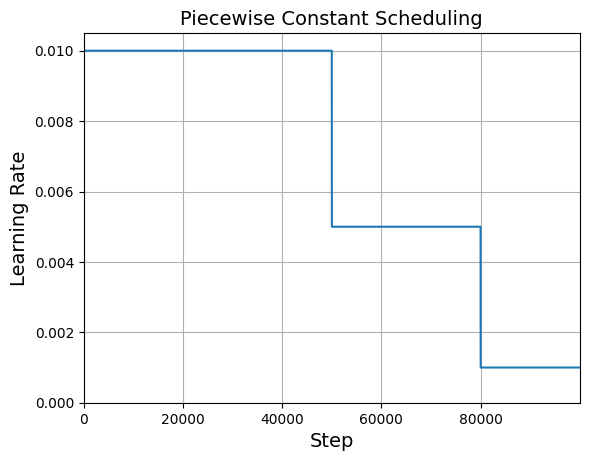

In [105]:
# extra code – this cell plots piecewise constant scheduling

boundaries = [50_000, 80_000]
values = [0.01, 0.005, 0.001]

steps = np.arange(100_000)

lrs = np.full(len(steps), values[0])
for boundary, value in zip(boundaries, values[1:]):
    lrs[boundary:] = value

plt.plot(steps, lrs, "-")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Piecewise Constant Scheduling", fontsize=14)
plt.grid(True)
plt.show()

Just like we did with exponential scheduling, we could also implement piecewise constant scheduling manually:

In [106]:
def piecewise_constant_fn(epoch):
    if epoch < 5:
        return 0.01
    elif epoch < 15:
        return 0.005
    else:
        return 0.001

In [107]:
# extra code – this cell demonstrates a more general way to define
#              piecewise constant scheduling.

def piecewise_constant(boundaries, values):
    boundaries = np.array([0] + boundaries)
    values = np.array(values)
    def piecewise_constant_fn(epoch):
        return values[(boundaries > epoch).argmax() - 1]
    return piecewise_constant_fn

piecewise_constant_fn = piecewise_constant([5, 15], [0.01, 0.005, 0.001])

In [108]:
# extra code – use a tf.keras.callbacks.LearningRateScheduler like earlier

n_epochs = 25

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(piecewise_constant_fn)

model = build_model()
optimizer = tf.keras.optimizers.Nadam(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/25
1719/1719 [==============================] - 14s 5ms/step - loss: 0.5468 - accuracy: 0.8073 - val_loss: 0.4997 - val_accuracy: 0.8164 - lr: 0.0100
Epoch 2/25
1719/1719 [==============================] - 8s 4ms/step - loss: 0.4521 - accuracy: 0.8403 - val_loss: 0.4848 - val_accuracy: 0.8364 - lr: 0.0100
Epoch 3/25
1719/1719 [==============================] - 8s 4ms/step - loss: 0.4297 - accuracy: 0.8495 - val_loss: 0.4554 - val_accuracy: 0.8500 - lr: 0.0100
Epoch 4/25
1719/1719 [==============================] - 8s 4ms/step - loss: 0.4214 - accuracy: 0.8522 - val_loss: 0.4147 - val_accuracy: 0.8540 - lr: 0.0100
Epoch 5/25
1719/1719 [==============================] - 8s 4ms/step - loss: 0.4108 - accuracy: 0.8571 - val_loss: 0.4080 - val_accuracy: 0.8586 - lr: 0.0100
Epoch 6/25
1719/1719 [==============================] - 8s 4ms/step - loss: 0.3579 - accuracy: 0.8708 - val_loss: 0.4006 - val_accuracy: 0.8626 - lr: 0.0050
Epoch 7/25
1719/1719 [==============================] - 8

We've looked at InverseTimeDecay, ExponentialDecay, and PiecewiseConstantDecay. A few more schedulers are available in tf.keras.optimizers.schedules, here is the full list:

In [109]:
for name in sorted(dir(tf.keras.optimizers.schedules)):
    if name[0] == name[0].lower():  # must start with capital letter
        continue
    scheduler_class = getattr(tf.keras.optimizers.schedules, name)
    print(f"• {name} – {scheduler_class.__doc__.splitlines()[0]}")

• CosineDecay – A LearningRateSchedule that uses a cosine decay with optional warmup.
• CosineDecayRestarts – A LearningRateSchedule that uses a cosine decay schedule with restarts.
• ExponentialDecay – A LearningRateSchedule that uses an exponential decay schedule.
• InverseTimeDecay – A LearningRateSchedule that uses an inverse time decay schedule.
• LearningRateSchedule – The learning rate schedule base class.
• PiecewiseConstantDecay – A LearningRateSchedule that uses a piecewise constant decay schedule.
• PolynomialDecay – A LearningRateSchedule that uses a polynomial decay schedule.


## Performance Scheduling

In [111]:
# extra code – build and compile the model

model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [114]:
import tensorflow as tf

class LrLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = self.model.optimizer.learning_rate
        
        # Works for both constant and scheduled LR
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(self.model.optimizer.iterations)
        
        logs["learning_rate"] = float(tf.keras.backend.get_value(lr))

In [115]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

history = model.fit(
    X_train, y_train,
    epochs=n_epochs,
    validation_data=(X_valid, y_valid),
    callbacks=[lr_scheduler, LrLogger()]  # <-- add this
)

Epoch 1/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2272 - accuracy: 0.9178 - val_loss: 0.3316 - val_accuracy: 0.8822 - lr: 0.0050 - learning_rate: 0.0050
Epoch 2/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2253 - accuracy: 0.9186 - val_loss: 0.3221 - val_accuracy: 0.8864 - lr: 0.0050 - learning_rate: 0.0050
Epoch 3/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2216 - accuracy: 0.9202 - val_loss: 0.3163 - val_accuracy: 0.8878 - lr: 0.0050 - learning_rate: 0.0050
Epoch 4/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2207 - accuracy: 0.9215 - val_loss: 0.3126 - val_accuracy: 0.8888 - lr: 0.0050 - learning_rate: 0.0050
Epoch 5/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2180 - accuracy: 0.9218 - val_loss: 0.3138 - val_accuracy: 0.8874 - lr: 0.0050 - learning_rate: 0.0050
Epoch 6/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2156 - accuracy: 

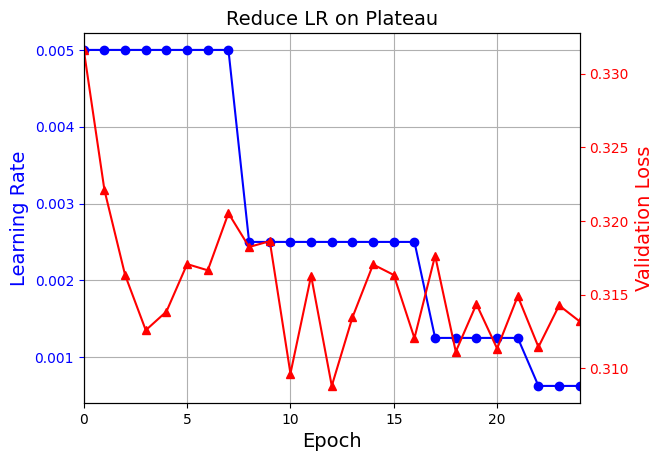

In [116]:
# extra code – this cell plots performance scheduling

plt.plot(history.epoch, history.history["learning_rate"], "bo-")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate", color='b')
plt.tick_params('y', colors='b')
plt.gca().set_xlim(0, n_epochs - 1)
plt.grid(True)

ax2 = plt.gca().twinx()
ax2.plot(history.epoch, history.history["val_loss"], "r^-")
ax2.set_ylabel('Validation Loss', color='r')
ax2.tick_params('y', colors='r')

plt.title("Reduce LR on Plateau", fontsize=14)
plt.show()

## 1Cycle scheduling
The ExponentialLearningRate custom callback updates the learning rate during training, at the end of each batch. It multiplies it by a constant factor. It also saves the learning rate and loss at each batch. Since logs["loss"] is actually the mean loss since the start of the epoch, and we want to save the batch loss instead, we must compute the mean times the number of batches since the beginning of the epoch to get the total loss so far, then we subtract the total loss at the previous batch to get the current batch's loss.

In [119]:
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_epoch_begin(self, epoch, logs=None):
        self.sum_of_epoch_losses = 0

    def on_batch_end(self, batch, logs=None):
        mean_epoch_loss = logs["loss"]  # the epoch's mean loss so far 
        new_sum_of_epoch_losses = mean_epoch_loss * (batch + 1)
        batch_loss = new_sum_of_epoch_losses - self.sum_of_epoch_losses
        self.sum_of_epoch_losses = new_sum_of_epoch_losses
        lr = self.model.optimizer.learning_rate.numpy()
        self.rates.append(lr)
        self.losses.append(batch_loss)
        self.model.optimizer.learning_rate = lr * self.factor

The find_learning_rate() function trains the model using the ExponentialLearningRate callback, and it returns the learning rates and corresponding batch losses. At the end, it restores the model and its optimizer to their initial state.

In [121]:
def find_learning_rate(model, X, y, epochs=1, batch_size=32, min_rate=1e-4,
                       max_rate=1):
    init_weights = model.get_weights()
    iterations = math.ceil(len(X) / batch_size) * epochs
    factor = (max_rate / min_rate) ** (1 / iterations)
    init_lr = K.get_value(model.optimizer.learning_rate)
    model.optimizer.learning_rate = min_rate
    exp_lr = ExponentialLearningRate(factor)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size,
                        callbacks=[exp_lr])
    model.optimizer.learning_rate = init_lr
    model.set_weights(init_weights)
    return exp_lr.rates, exp_lr.losses

The plot_lr_vs_loss() function plots the learning rates vs the losses. The optimal learning rate to use as the maximum learning rate in 1cycle is near the bottom of the curve.

In [123]:
def plot_lr_vs_loss(rates, losses):
    plt.plot(rates, losses, "b")
    plt.gca().set_xscale('log')
    max_loss = losses[0] + min(losses)
    plt.hlines(min(losses), min(rates), max(rates), color="k")
    plt.axis([min(rates), max(rates), 0, max_loss])
    plt.xlabel("Learning rate")
    plt.ylabel("Loss")
    plt.grid()

Let's build a simple Fashion MNIST model and compile it:

In [125]:
model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

Now let's find the optimal max learning rate for 1cycle:

430/430 [==============================] - 5s 7ms/step - loss: 1.8622 - accuracy: 0.3773


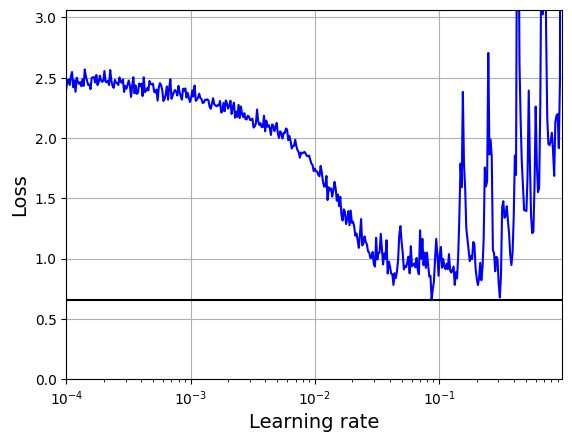

In [127]:
batch_size = 128
rates, losses = find_learning_rate(model, X_train, y_train, epochs=1,
                                   batch_size=batch_size)
plot_lr_vs_loss(rates, losses)

Looks like the max learning rate to use for 1cycle is around 10–1.

The OneCycleScheduler custom callback updates the learning rate at the beginning of each batch. It applies the logic described in the book: increase the learning rate linearly during about half of training, then reduce it linearly back to the initial learning rate, and lastly reduce it down to close to zero linearly for the very last part of training.

In [129]:
class OneCycleScheduler(tf.keras.callbacks.Callback):
    def __init__(self, iterations, max_lr=1e-3, start_lr=None,
                 last_iterations=None, last_lr=None):
        self.iterations = iterations
        self.max_lr = max_lr
        self.start_lr = start_lr or max_lr / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_lr = last_lr or self.start_lr / 1000
        self.iteration = 0

    def _interpolate(self, iter1, iter2, lr1, lr2):
        return (lr2 - lr1) * (self.iteration - iter1) / (iter2 - iter1) + lr1

    def on_batch_begin(self, batch, logs):
        if self.iteration < self.half_iteration:
            lr = self._interpolate(0, self.half_iteration, self.start_lr,
                                   self.max_lr)
        elif self.iteration < 2 * self.half_iteration:
            lr = self._interpolate(self.half_iteration, 2 * self.half_iteration,
                                   self.max_lr, self.start_lr)
        else:
            lr = self._interpolate(2 * self.half_iteration, self.iterations,
                                   self.start_lr, self.last_lr)
        self.iteration += 1
        self.model.optimizer.learning_rate = lr

Let's build and compile a simple Fashion MNIST model, then train it using the OneCycleScheduler callback:

In [131]:
model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"])
n_epochs = 25
onecycle = OneCycleScheduler(math.ceil(len(X_train) / batch_size) * n_epochs,
                             max_lr=0.1)
history = model.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(X_valid, y_valid),
                    callbacks=[onecycle])

Epoch 1/25
430/430 [==============================] - 5s 8ms/step - loss: 0.9321 - accuracy: 0.6889 - val_loss: 0.5902 - val_accuracy: 0.8026
Epoch 2/25
430/430 [==============================] - 3s 6ms/step - loss: 0.5639 - accuracy: 0.8036 - val_loss: 0.4864 - val_accuracy: 0.8268
Epoch 3/25
430/430 [==============================] - 3s 6ms/step - loss: 0.4931 - accuracy: 0.8259 - val_loss: 0.4614 - val_accuracy: 0.8384
Epoch 4/25
430/430 [==============================] - 3s 6ms/step - loss: 0.4492 - accuracy: 0.8407 - val_loss: 0.4245 - val_accuracy: 0.8496
Epoch 5/25
430/430 [==============================] - 3s 6ms/step - loss: 0.4239 - accuracy: 0.8475 - val_loss: 0.4209 - val_accuracy: 0.8428
Epoch 6/25
430/430 [==============================] - 3s 6ms/step - loss: 0.3976 - accuracy: 0.8571 - val_loss: 0.4993 - val_accuracy: 0.8110
Epoch 7/25
430/430 [==============================] - 3s 6ms/step - loss: 0.3829 - accuracy: 0.8620 - val_loss: 0.4227 - val_accuracy: 0.8416
Epoch 